# Forecast baseline

Проверка того, насколько вообще можно надёжно прогнозировать дневную выручку на короткой истории продаж.

Цель здесь не построить сложную модель, а выполнить честный backtest простых baseline-подходов и количественно оценить ограничение данных.

Используются только реальные продажи из `data/sales_mart.csv`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.options.display.float_format = "{:,.2f}".format

In [2]:
def find_repo_root() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (candidate / "data" / "sales_mart.csv").exists():
            return candidate
    raise FileNotFoundError("Не найден data/sales_mart.csv")

REPO_ROOT = find_repo_root()
SALES_MART_PATH = REPO_ROOT / "data" / "sales_mart.csv"

sales = pd.read_csv(SALES_MART_PATH)
sales["timestamp"] = pd.to_datetime(sales["timestamp"])

print(f"Файл: {SALES_MART_PATH}")
print(f"Заказов: {len(sales)}")
print(f"Период: {sales['timestamp'].min()} — {sales['timestamp'].max()}")

Файл: c:\Users\gatil\Desktop\postupashki-marketing-analytics\data\sales_mart.csv
Заказов: 628
Период: 2026-08-04 09:08:31 — 2026-09-10 06:09:12


## Подготовка дневного ряда

10 сентября в исходном файле заканчивается в 06:09 и содержит только часть дня, поэтому последний календарный день исключаем из backtest. Иначе модель штрафовалась бы за неполный день, а не за ошибку прогноза.

In [3]:
sales["date"] = sales["timestamp"].dt.normalize()

daily = (
    sales.groupby("date", as_index=False)
    .agg(
        orders=("order_id", "count"),
        revenue=("order_revenue", "sum"),
    )
    .sort_values("date")
)

last_observed_date = sales["timestamp"].max().normalize()
daily_full = daily[daily["date"] < last_observed_date].copy()

print(f"Полных дней: {len(daily_full)}")
print(f"Backtest использует данные по {daily_full['date'].max().date()} включительно")

daily_full.tail(10)

Полных дней: 37
Backtest использует данные по 2026-09-09 включительно


,date,orders,revenue
27,2026-08-31,19,"206,188.00"
28,2026-09-01,19,"226,880.00"
29,2026-09-02,23,"217,280.00"
30,2026-09-03,20,"180,400.00"
31,2026-09-04,26,"269,585.00"
32,2026-09-05,49,"484,684.00"
33,2026-09-06,45,"396,075.00"
34,2026-09-07,17,"173,375.00"
35,2026-09-08,6,"64,750.00"
36,2026-09-09,16,"193,600.00"


## Backtest

Используем rolling one-step-ahead backtest на последних 14 полных днях.

Для каждого тестового дня прогноз строится только по данным, которые были доступны до этого дня.

Сравниваем четыре простых baseline:

- выручка предыдущего дня;
- медиана последних 7 дней;
- среднее последних 7 дней;
- тот же день недели неделю назад.

Основная метрика — WAPE:

`sum(|actual - forecast|) / sum(actual)`

Дополнительно считаем MAE в рублях.

In [4]:
series = daily_full.set_index("date")["revenue"].sort_index()

test_dates = series.index[-14:]
rows = []

for date in test_dates:
    history = series[series.index < date]
    actual = series.loc[date]

    rows.append(
        {
            "date": date,
            "actual": actual,
            "previous_day": history.iloc[-1],
            "median_7d": history.iloc[-7:].median(),
            "mean_7d": history.iloc[-7:].mean(),
            "same_weekday_last_week": series.loc[date - pd.Timedelta(days=7)],
        }
    )

backtest = pd.DataFrame(rows)
backtest

,date,actual,previous_day,median_7d,mean_7d,same_weekday_last_week
0,2026-08-27,"137,425.00","84,075.00","141,650.00","162,310.43","52,585.00"
1,2026-08-28,"60,200.00","137,425.00","141,650.00","174,430.43","28,145.00"
2,2026-08-29,"95,525.00","60,200.00","141,650.00","179,009.71","251,150.00"
3,2026-08-30,"176,340.00","95,525.00","137,425.00","156,777.57","394,495.00"
4,2026-08-31,"206,188.00","176,340.00","137,425.00","125,612.57","184,073.00"
5,2026-09-01,"226,880.00","206,188.00","137,425.00","128,771.86","141,650.00"
6,2026-09-02,"217,280.00","226,880.00","137,425.00","140,947.57","84,075.00"
7,2026-09-03,"180,400.00","217,280.00","176,340.00","159,976.86","137,425.00"
8,2026-09-04,"269,585.00","180,400.00","180,400.00","166,116.14","60,200.00"
9,2026-09-05,"484,684.00","269,585.00","206,188.00","196,028.29","95,525.00"


In [5]:
model_names = {
    "previous_day": "Previous day",
    "median_7d": "7-day median",
    "mean_7d": "7-day mean",
    "same_weekday_last_week": "Same weekday last week",
}

metrics = []

for column, model_name in model_names.items():
    absolute_error = (backtest[column] - backtest["actual"]).abs()

    metrics.append(
        {
            "model": model_name,
            "MAE_RUB": absolute_error.mean(),
            "WAPE_pct": absolute_error.sum() / backtest["actual"].sum() * 100,
        }
    )

metrics = (
    pd.DataFrame(metrics)
    .sort_values("WAPE_pct")
    .reset_index(drop=True)
)

metrics

,model,MAE_RUB,WAPE_pct
0,Previous day,"85,485.93",41.52
1,7-day median,"85,617.07",41.59
2,7-day mean,"102,782.65",49.92
3,Same weekday last week,"129,364.43",62.84


In [6]:
best = metrics.iloc[0]

print(
    f"Лучший baseline: {best['model']}\n"
    f"WAPE: {best['WAPE_pct']:.1f}%\n"
    f"MAE: {best['MAE_RUB']:,.0f} ₽"
)

Лучший baseline: Previous day
WAPE: 41.5%
MAE: 85,486 ₽


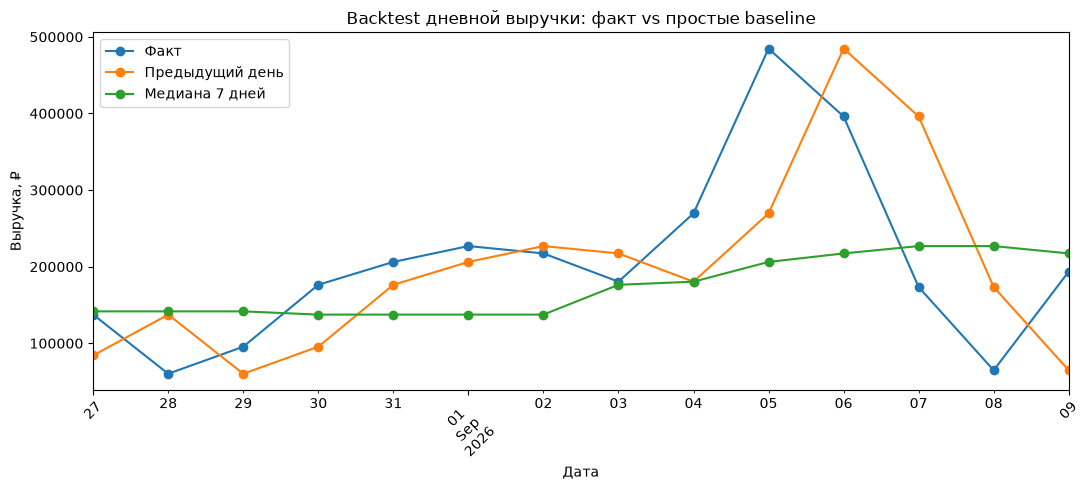

In [7]:
plot_df = backtest.set_index("date")

ax = plot_df[["actual", "previous_day", "median_7d"]].plot(
    figsize=(11, 5),
    marker="o",
)

ax.set_title("Backtest дневной выручки: факт vs простые baseline")
ax.set_xlabel("Дата")
ax.set_ylabel("Выручка, ₽")
ax.legend(["Факт", "Предыдущий день", "Медиана 7 дней"])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Вывод

Лучший из проверенных простых baseline — прогноз выручкой предыдущего дня.

На последних 14 полных днях:

- WAPE ≈ **41.5%**;
- MAE ≈ **85.5 тыс. ₽**.

Для бизнес-решения о распределении рекламного бюджета такая ошибка слишком велика. История продаж короткая и содержит резкие всплески, а в исторических данных отсутствуют ключевые маркетинговые признаки, которые объясняют эти изменения.

Поэтому мы не используем точечный прогноз как основу для распределения следующих 300 000 ₽.

Для будущего прогнозирования нужно накапливать более длинную историю и признаки:

- `ad_spend`;
- `placements`;
- `sale_post`;
- `discount`;
- `launch`;
- `channel`;
- `creative`.

И уже после этого повторять backtest и сравнивать модель с простым baseline.